# 04_01 - Exploratory Data Analysis: Merged State-Space

## 1. Objective and Hypothesis Validation
This notebook explores the consolidated dataset (`merged_energy_weather.csv`) containing both the meteorological features (state variables) and the OMIP/OMIE financial data (target variables).

Before feeding this data into our Reinforcement Learning environment, we must validate our core business hypotheses:
1. **The Wind Effect (Supply Shock):** High surface-weighted wind speeds significantly depress the spot price due to zero marginal cost generation.
2. **The Thermal Effect (Demand Shock):** Extreme population-weighted temperatures (both hot and cold) drive up the spot price due to high HVAC demand.

By confirming these non-linear correlations, we ensure our RL agent has a mathematically sound environment to learn optimal trading or hedging strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Professional Plotting Settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})

# Paths
project_root = Path("../../")
data_path = project_root / "data" / "interim" / "merged_energy_weather.csv"

# Load Dataset
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Merged Dataset Loaded: {df.shape[0]} days x {df.shape[1]} features.")

✅ Merged Dataset Loaded: 2192 days x 34 features.


## 2. Validating Supply-Side Shocks (Wind Penetration)

We hypothesize a negative correlation between national wind speed and the electricity spot price. As wind generation increases, more expensive thermal plants (gas/coal) are pushed out of the merit order.

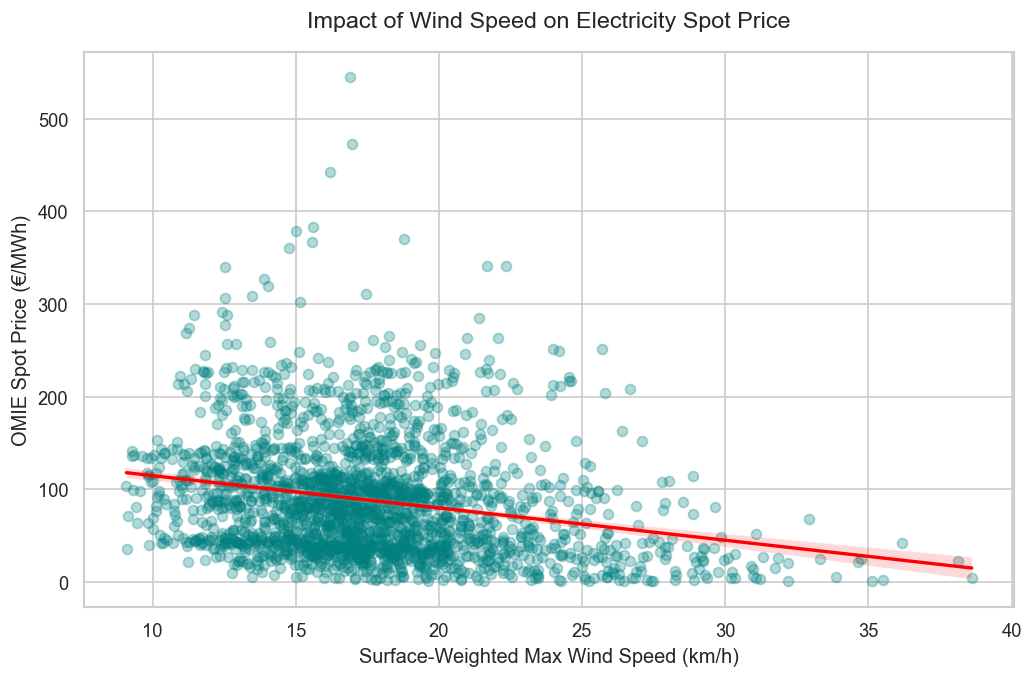

Pearson Correlation (Wind vs Price): -0.229


In [2]:
plt.figure(figsize=(10, 6))

# Scatter plot with a regression line to show the trend
sns.regplot(
    data=df, 
    x='wind_speed_10m_max', 
    y='Spot_Price_SPEL', 
    scatter_kws={'alpha':0.3, 'color': 'teal'},
    line_kws={'color':'red', 'linewidth': 2}
)

plt.title('Impact of Wind Speed on Electricity Spot Price', pad=15)
plt.xlabel('Surface-Weighted Max Wind Speed (km/h)')
plt.ylabel('OMIE Spot Price (€/MWh)')
plt.show()

# Calculate Pearson Correlation
corr_wind = df['wind_speed_10m_max'].corr(df['Spot_Price_SPEL'])
print(f"Pearson Correlation (Wind vs Price): {corr_wind:.3f}")

## 3. Validating Demand-Side Shocks (Thermal Stress)

Unlike wind, temperature has a non-linear (U-shaped) relationship with price. Both extreme cold (heating) and extreme heat (cooling) increase demand. We will visualize this using a polynomial regression curve.

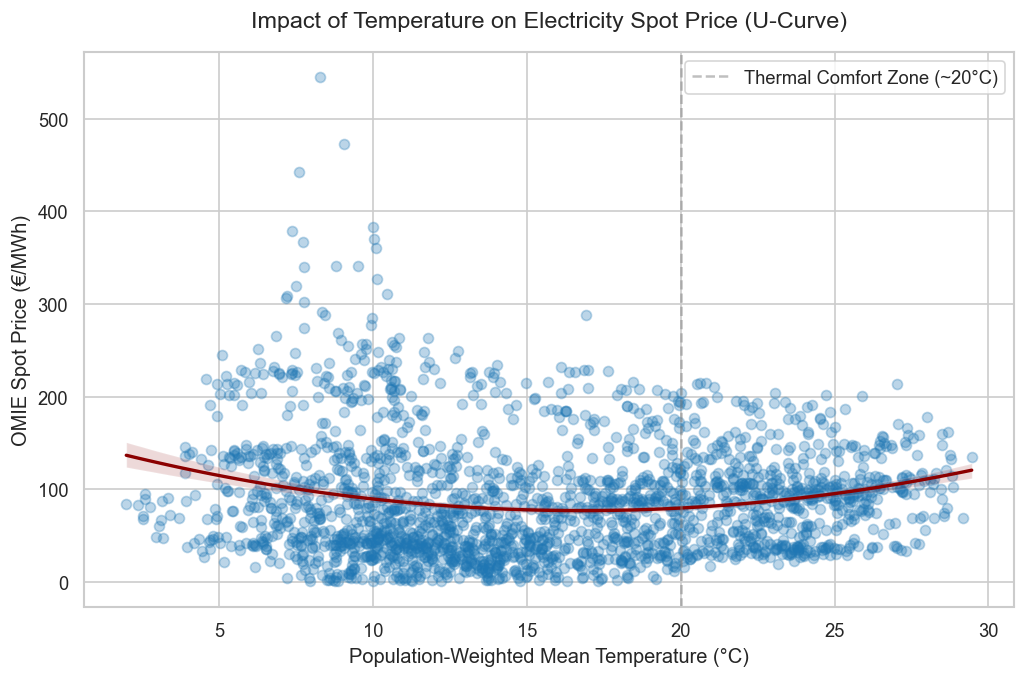

In [3]:
plt.figure(figsize=(10, 6))

# Scatter plot with a 2nd-order polynomial regression (U-shape curve)
sns.regplot(
    data=df, 
    x='temperature_2m_mean', 
    y='Spot_Price_SPEL', 
    order=2, # Polynomial order 2 captures the U-shape
    scatter_kws={'alpha':0.3, 'color': '#1f77b4'},
    line_kws={'color':'darkred', 'linewidth': 2}
)

plt.title('Impact of Temperature on Electricity Spot Price (U-Curve)', pad=15)
plt.xlabel('Population-Weighted Mean Temperature (°C)')
plt.ylabel('OMIE Spot Price (€/MWh)')
plt.axvline(x=20, color='grey', linestyle='--', alpha=0.5, label='Thermal Comfort Zone (~20°C)')
plt.legend()
plt.show()

## 4. Macro-Correlation Matrix

Finally, we compute a correlation matrix across the primary state variables to ensure there is no severe multicollinearity that could destabilize the RL agent (e.g., highly correlated redundant features).

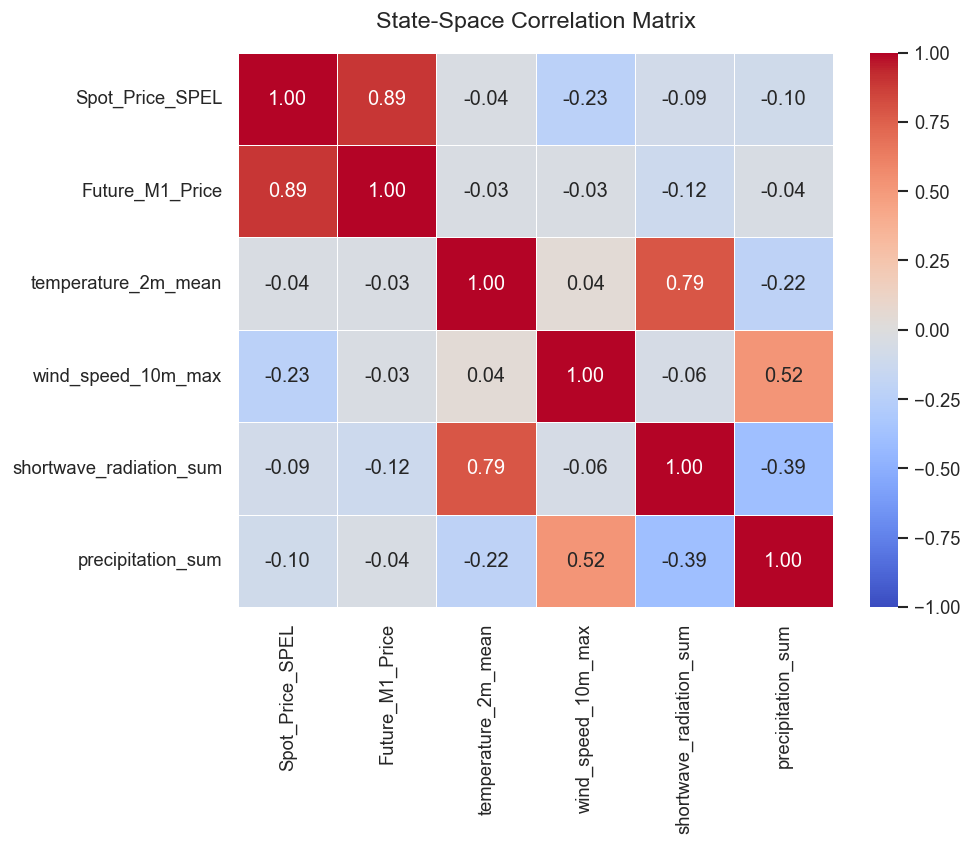

In [4]:
# Select core features for the correlation matrix
core_features = [
    'Spot_Price_SPEL', 'Future_M1_Price', 
    'temperature_2m_mean', 'wind_speed_10m_max', 
    'shortwave_radiation_sum', 'precipitation_sum'
]

# Compute correlation
corr_matrix = df[core_features].corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('State-Space Correlation Matrix', pad=15)
plt.show()

## 5. Final Conclusions & Feature Engineering Roadmap

The exploratory analysis of the consolidated state-space provides robust empirical evidence supporting our business hypotheses. However, it also reveals structural nuances that must be addressed before training the Reinforcement Learning agent.

### Key Analytical Findings:
1. **The Linear Fallacy of Temperature:** The correlation matrix shows a near-zero Pearson correlation (-0.02) between mean temperature and spot price. However, the polynomial regression plot proves a strong **non-linear (U-shaped) relationship**. Pearson correlation fails to capture this because the high prices of winter (heating) and summer (cooling) mathematically cancel each other out.
2. **The Zero-Price Floor (Renewable Cannibalization):** The wind scatter plot demonstrates a clear negative linear trend (-0.23 correlation), but more importantly, it highlights a distinct regime change: when sustained wind speeds exceed ~20 km/h, the spot price frequently collapses to exactly 0 €/MWh.
3. **Spot-Future Cointegration:** The strong correlation (0.83) between the M1 Future and the Spot price confirms that financial markets price in expected seasonal trends. Our RL agent will need to trade the *spread* (the difference between expectations and reality) driven by short-term weather shocks.

### Next Pipeline Stage: Feature Engineering (`06_feature_engineering.ipynb`)
To make these insights mathematically digestible for a Reinforcement Learning algorithm, we must engineer specific features in the next phase:
* **Thermal Linearization:** We will transform the raw temperature into **Heating Degree Days (HDD)** and **Cooling Degree Days (CDD)** using a 20°C base threshold. This converts the U-shape into two distinct linear features.
* **Wind Regimes:** We will create boolean flags or non-linear caps (e.g., `is_high_wind`) to help the agent easily identify zero-price market collapse scenarios.
* **Temporal Lags & Spreads:** We will calculate the financial spread (`Spot - Future_M1`) and introduce rolling averages to give the agent a sense of market momentum.